# 내화물 초음파 검사 반복측정 데이터 EDA

**실험 설계**
- 내화물 30개, 각 9가지 조건 × 2회 반복 = 18회/개
- Human Error 요인 1 — 프로브 각도: `v`(평행) / `m`(중간) / `h`(큰 각)
- Human Error 요인 2 — 젤 도포량: `s`(적음) / `m`(적정) / `l`(많음)
- 이름 형식: `SRB-71C_40160_{id}_{angle}{gel}{trial}`

## 0. 라이브러리 & 설정

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import font_manager
import seaborn as sns
from scipy import stats
import re
import shutil
import warnings
warnings.filterwarnings('ignore')

cache_dir = matplotlib.get_cachedir()

sns.set_theme(style='whitegrid', palette='muted')

font_path = 'C:/Windows/Fonts/malgun.ttf'   # Windows 경로
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = 'data/0910 반복측정 데이터.csv'
N_META_COLS = 31   # 신호 데이터 이전 메타데이터 컬럼 수
SKIP_ROWS   = 15   # PL-Link 헤더 메타데이터 행 수

## 1. 데이터 로드

In [161]:
# 메타데이터 컬럼만 먼저 로드 (신호 7932열은 별도 처리)
raw = pd.read_csv(
    DATA_PATH,
    encoding='utf-16',
    sep='\t',
    skiprows=SKIP_ROWS,
    header=0,
    low_memory=False
)

print(f'전체 shape: {raw.shape}')
print(f'컬럼 수: {len(raw.columns)} (메타 {N_META_COLS}개 + 신호 {len(raw.columns)-N_META_COLS}개)')
raw.iloc[:, :N_META_COLS].head(3)

전체 shape: (528, 7963)
컬럼 수: 7963 (메타 31개 + 신호 7932개)


,SW 버전,측정 유형,결과,이름,날짜 & 시간,라벨,측정 번호,시간 1 (µs),속도 (m/s),거리 (m),...,Compr. 강도 단위,트리거,트리거 진폭 (%),표시 진폭 (%),전송 모드,게이트 활성화,게이트 시작 시간 (µs),게이트 중지 시간 (µs),의견,신호 크기
0,3.0.12,펀스 속도,2614 m/s,SRB-71C_40160_01_vm1,2025-09-08 11:35,1,1,153,2614,0.4,...,--,자동,0,--,버스트,N,76,600,NaN,7932
1,3.0.12,펀스 속도,2516 m/s,SRB-71C_40160_01_vm2,2025-09-08 13:33,1,1,159,2516,0.4,...,--,자동,0,--,버스트,N,76,600,NaN,7932
2,3.0.12,펀스 속도,2703 m/s,SRB-71C_40160_01_vl1,2025-09-08 13:33,1,1,148,2703,0.4,...,--,자동,0,--,버스트,N,76,600,NaN,7932


In [162]:
# 메타데이터와 신호 분리
meta = raw.iloc[:, :N_META_COLS].copy()
signal = raw.iloc[:, N_META_COLS:].copy().astype(np.float32)

# 컬럼 이름 정리
meta.columns = [
    'sw_ver', 'meas_type', 'result', 'name', 'datetime',
    'label', 'meas_no', 'time_us', 'velocity_mps', 'distance_m',
    'meas_range', 'probe_freq_kHz', 'probe_type', 'probe_gain',
    'pulse_voltage', 'prf_Hz', 'calib_offset_us', 'calib_factor',
    'tgc', 'unit', 'amp_unit', 'compr_unit', 'trigger',
    'trig_amp_pct', 'disp_amp_pct', 'tx_mode', 'gate_active',
    'gate_start_us', 'gate_stop_us', 'comment', 'signal_size'
]
signal.columns = [f's{i}' for i in range(len(signal.columns))]

meta.head(3)

,sw_ver,meas_type,result,name,datetime,label,meas_no,time_us,velocity_mps,distance_m,...,compr_unit,trigger,trig_amp_pct,disp_amp_pct,tx_mode,gate_active,gate_start_us,gate_stop_us,comment,signal_size
0,3.0.12,펀스 속도,2614 m/s,SRB-71C_40160_01_vm1,2025-09-08 11:35,1,1,153,2614,0.4,...,--,자동,0,--,버스트,N,76,600,NaN,7932
1,3.0.12,펀스 속도,2516 m/s,SRB-71C_40160_01_vm2,2025-09-08 13:33,1,1,159,2516,0.4,...,--,자동,0,--,버스트,N,76,600,NaN,7932
2,3.0.12,펀스 속도,2703 m/s,SRB-71C_40160_01_vl1,2025-09-08 13:33,1,1,148,2703,0.4,...,--,자동,0,--,버스트,N,76,600,NaN,7932


## 2. 이름 파싱 — 실험 변수 추출

In [163]:
PATTERN = re.compile(
    r'SRB-71C_40160_(?P<id>\d+)_(?P<angle>[vmh])(?P<gel>[sml])(?P<trial>\d+)'
)

def parse_name(name):
    m = PATTERN.search(str(name))
    if m:
        return pd.Series({
            'sample_id': int(m.group('id')),
            'angle':     m.group('angle'),
            'gel':       m.group('gel'),
            'trial':     int(m.group('trial')),
            'condition': m.group('angle') + m.group('gel'),
        })
    return pd.Series({'sample_id': np.nan, 'angle': np.nan,
                      'gel': np.nan, 'trial': np.nan, 'condition': np.nan})

parsed = meta['name'].apply(parse_name)
df = pd.concat([meta, parsed], axis=1)

# 타입 정리
df['label']        = pd.to_numeric(df['label'], errors='coerce').astype('Int64')
df['velocity_mps'] = pd.to_numeric(df['velocity_mps'], errors='coerce')
df['time_us']      = pd.to_numeric(df['time_us'], errors='coerce')
df['datetime']     = pd.to_datetime(df['datetime'], errors='coerce')

# 파싱 실패 행 확인
failed = df[df['sample_id'].isna()]
if len(failed):
    print(f'파싱 실패 {len(failed)}행:')
    print(failed['name'].tolist())

df = df.dropna(subset=['sample_id']).reset_index(drop=True)
print(f'유효 데이터: {len(df)}행')
df[['name','sample_id','angle','gel','trial','condition','label','velocity_mps']].head(10)

유효 데이터: 528행


,name,sample_id,angle,gel,trial,condition,label,velocity_mps
0,SRB-71C_40160_01_vm1,1,v,m,1,vm,1,2614
1,SRB-71C_40160_01_vm2,1,v,m,2,vm,1,2516
2,SRB-71C_40160_01_vl1,1,v,l,1,vl,1,2703
3,SRB-71C_40160_01_hl2,1,h,l,2,hl,1,2581
4,SRB-71C_40160_02_vl1,2,v,l,1,vl,0,2857
5,SRB-71C_40160_02_vl2,2,v,l,2,vl,0,2857
6,SRB-71C_40160_02_vs1,2,v,s,1,vs,0,2857
7,SRB-71C_40160_02_vs2,2,v,s,2,vs,0,2857
8,SRB-71C_40160_02_vm1,2,v,m,1,vm,0,2837
9,SRB-71C_40160_02_vm2,2,v,m,2,vm,0,2857


In [164]:
# 빠진 측정 확인: 30개 내화물 × 9조건 × 2trial = 540개 기대
all_ids    = range(1, 31)
all_conds  = [a+g for a in ['v','m','h'] for g in ['s','m','l']]
all_trials = [1, 2]

expected = pd.MultiIndex.from_product(
    [all_ids, all_conds, all_trials],
    names=['sample_id', 'condition', 'trial']
)
actual = pd.MultiIndex.from_frame(
    df[['sample_id', 'condition', 'trial']].astype({'sample_id': int, 'trial': int})
)

# 중복 행 (같은 조합이 2회 이상 기록된 것)
dupes = df[df.duplicated(subset=['sample_id', 'condition', 'trial'], keep=False)] \
          .sort_values(['sample_id', 'condition', 'trial'])

# 빠진 조합 (expected에 있지만 actual에 없는 것)
missing = expected.difference(actual)

print(f'기대 측정 수        : {len(expected)}')
print(f'실제 행 수          : {len(actual)}')
print(f'고유 조합 수        : {actual.nunique()}')
print(f'중복 행 수          : {len(dupes)}  (= 실제 행 - 고유 조합)')
print(f'빠진 고유 조합 수   : {len(missing)}')
print()

if len(dupes):
    print('─── 중복 행 ───')
    print(dupes[['name', 'sample_id', 'condition', 'trial', 'velocity_mps']].to_string(index=False))
    print()

if len(missing):
    print('─── 빠진 측정 ───')
    print(missing.to_frame(index=False).to_string(index=False))
else:
    print('빠진 측정 없음')

기대 측정 수        : 540
실제 행 수          : 528
고유 조합 수        : 528
중복 행 수          : 0  (= 실제 행 - 고유 조합)
빠진 고유 조합 수   : 15

─── 빠진 측정 ───
 sample_id condition  trial
         1        hl      1
         1        hm      1
         1        hm      2
         1        hs      1
         1        hs      2
         1        ml      1
         1        ml      2
         1        mm      1
         1        mm      2
         1        ms      1
         1        ms      2
         1        vl      2
         1        vs      1
         1        vs      2
         2        hm      1


## 3. 기본 통계

In [165]:
print('=== 샘플 분포 ===')
print(f"내화물 수: {df['sample_id'].nunique()}")
print(f"조건 수: {df['condition'].nunique()} → {sorted(df['condition'].unique())}")
print(f"Trial 수: {sorted(df['trial'].unique())}")
print()
print('=== 라벨 분포 (균열 여부) ===')
label_counts = df.groupby('label')['sample_id'].nunique()
print(label_counts.rename({0:'정상(0)', 1:'균열(1)'}))
print()
print('=== 속도 기술 통계 (m/s) ===')
print(df['velocity_mps'].describe().round(1))

=== 샘플 분포 ===
내화물 수: 30
조건 수: 9 → ['hl', 'hm', 'hs', 'ml', 'mm', 'ms', 'vl', 'vm', 'vs']
Trial 수: [1, 2, 3]

=== 라벨 분포 (균열 여부) ===
label
정상(0)    27
균열(1)     3
Name: sample_id, dtype: int64

=== 속도 기술 통계 (m/s) ===
count     528.0
mean     2825.8
std       100.6
min      1575.0
25%      2778.0
50%      2837.0
75%      2878.0
max      3008.0
Name: velocity_mps, dtype: float64


In [166]:
# 조건별 측정 횟수 확인 (불균형 여부)
count_table = df.groupby(['angle','gel']).size().unstack(fill_value=0)
print('조건별 측정 횟수')
display(count_table)

조건별 측정 횟수


gel,l,m,s
angle,,,
h,59,57,59
m,58,58,58
v,59,60,60


## 4. 속도 분포 시각화

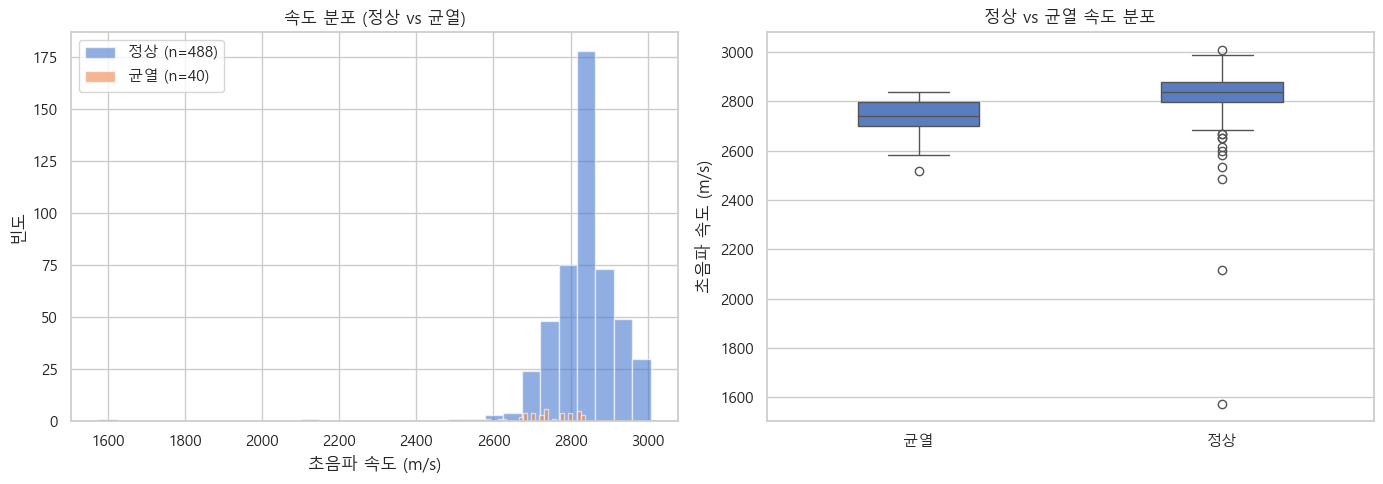

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 속도 히스토그램
ax = axes[0]
for lbl, grp in df.groupby('label'):
    ax.hist(grp['velocity_mps'].dropna(), bins=30, alpha=0.6,
            label=f"{'균열' if lbl==1 else '정상'} (n={len(grp)})")
ax.set_xlabel('초음파 속도 (m/s)')
ax.set_ylabel('빈도')
ax.set_title('속도 분포 (정상 vs 균열)')
ax.legend()

# 박스플롯
ax = axes[1]
df['label_str'] = df['label'].map({0:'정상', 1:'균열'})
sns.boxplot(data=df, x='label_str', y='velocity_mps', ax=ax, width=0.4)
ax.set_xlabel('')
ax.set_ylabel('초음파 속도 (m/s)')
ax.set_title('정상 vs 균열 속도 분포')

plt.tight_layout()
plt.show()

## 5. Human Error 요인 1 — 프로브 각도의 영향

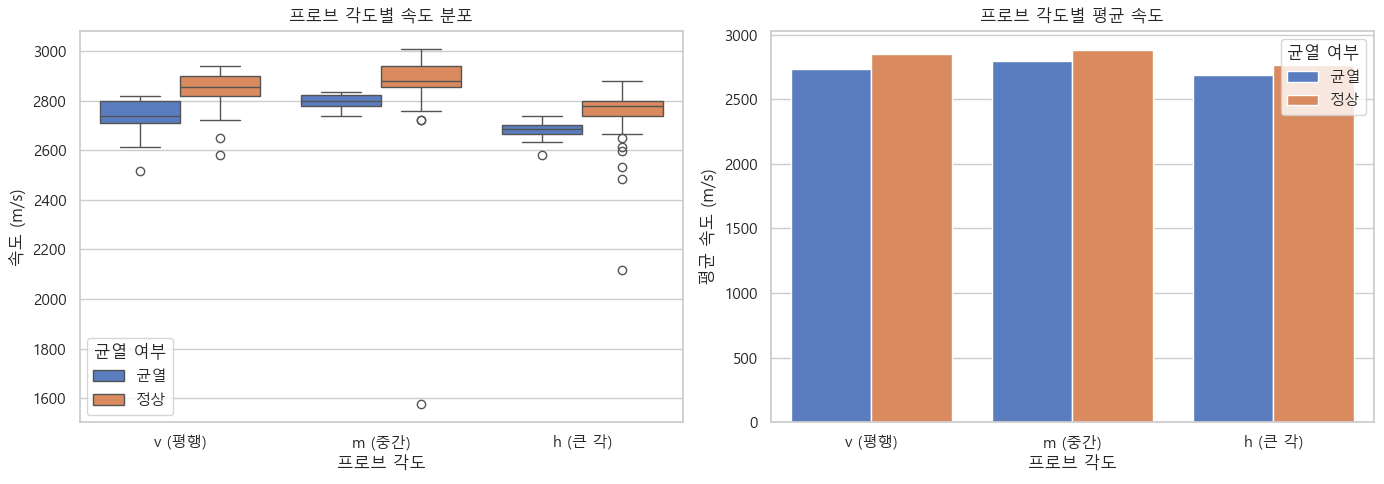

One-way ANOVA (프로브 각도): F=76.776, p=0.0000


In [168]:
angle_order = ['v', 'm', 'h']
angle_labels = {'v': 'v (평행)', 'm': 'm (중간)', 'h': 'h (큰 각)'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 박스플롯
ax = axes[0]
df['angle_label'] = df['angle'].map(angle_labels)
order = [angle_labels[a] for a in angle_order]
sns.boxplot(data=df, x='angle_label', y='velocity_mps', order=order,
            hue='label_str', ax=ax)
ax.set_xlabel('프로브 각도')
ax.set_ylabel('속도 (m/s)')
ax.set_title('프로브 각도별 속도 분포')
ax.legend(title='균열 여부')

# 각도별 평균 속도 (정상/균열 분리)
ax = axes[1]
angle_stats = df.groupby(['angle_label', 'label_str'])['velocity_mps'].mean().reset_index()
sns.barplot(data=angle_stats, x='angle_label', y='velocity_mps', hue='label_str',
            order=order, ax=ax)
ax.set_xlabel('프로브 각도')
ax.set_ylabel('평균 속도 (m/s)')
ax.set_title('프로브 각도별 평균 속도')
ax.legend(title='균열 여부')

plt.tight_layout()
plt.show()

# One-way ANOVA
groups = [df[df['angle']==a]['velocity_mps'].dropna() for a in angle_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f'One-way ANOVA (프로브 각도): F={f_stat:.3f}, p={p_val:.4f}')

## 6. Human Error 요인 2 — 젤 도포량의 영향

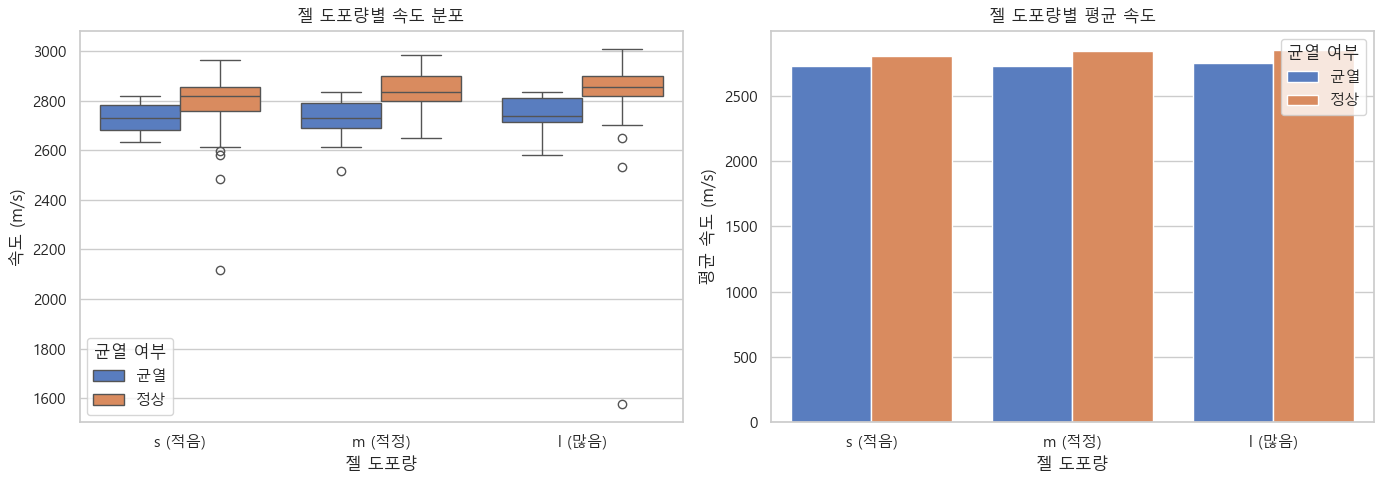

One-way ANOVA (젤 도포량): F=8.947, p=0.0002


In [169]:
gel_order = ['s', 'm', 'l']
gel_labels = {'s': 's (적음)', 'm': 'm (적정)', 'l': 'l (많음)'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
df['gel_label'] = df['gel'].map(gel_labels)
order_g = [gel_labels[g] for g in gel_order]
sns.boxplot(data=df, x='gel_label', y='velocity_mps', order=order_g,
            hue='label_str', ax=ax)
ax.set_xlabel('젤 도포량')
ax.set_ylabel('속도 (m/s)')
ax.set_title('젤 도포량별 속도 분포')
ax.legend(title='균열 여부')

ax = axes[1]
gel_stats = df.groupby(['gel_label', 'label_str'])['velocity_mps'].mean().reset_index()
sns.barplot(data=gel_stats, x='gel_label', y='velocity_mps', hue='label_str',
            order=order_g, ax=ax)
ax.set_xlabel('젤 도포량')
ax.set_ylabel('평균 속도 (m/s)')
ax.set_title('젤 도포량별 평균 속도')
ax.legend(title='균열 여부')

plt.tight_layout()
plt.show()

groups = [df[df['gel']==g]['velocity_mps'].dropna() for g in gel_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f'One-way ANOVA (젤 도포량): F={f_stat:.3f}, p={p_val:.4f}')

## 7. 9가지 조건 전체 비교

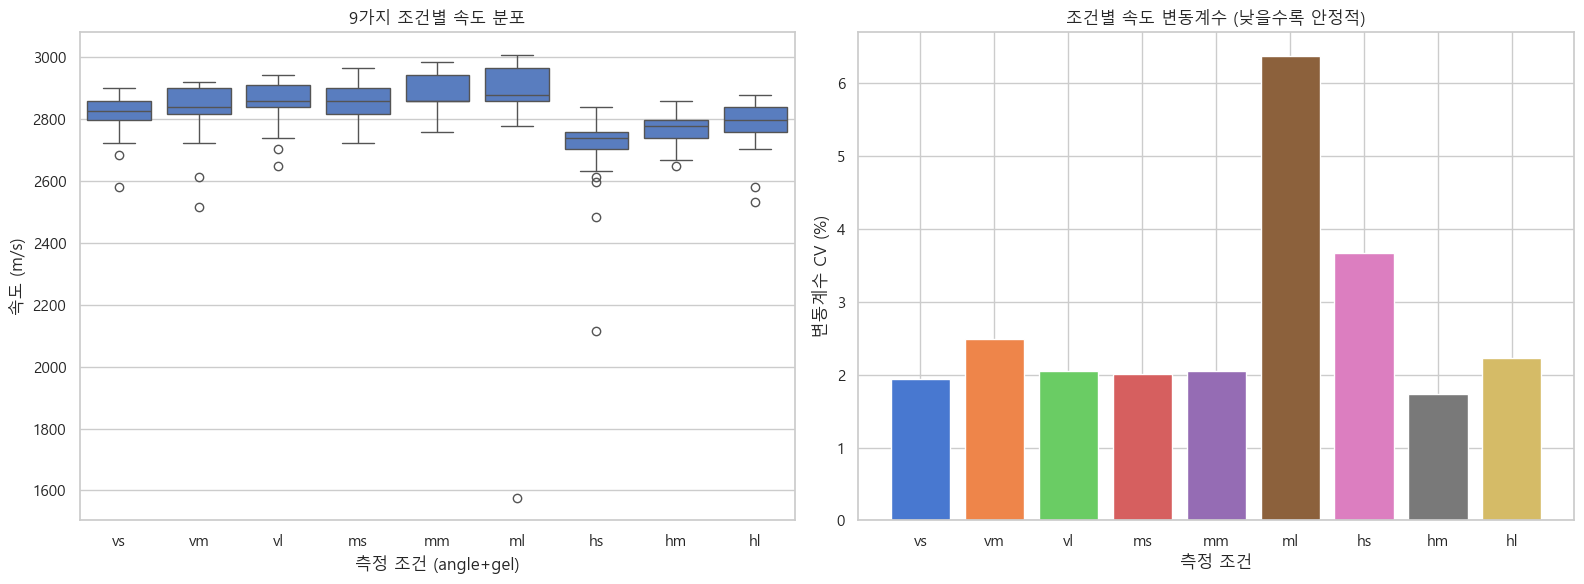

,mean,std,cv_pct
condition,,,
vs,2822.35,54.85,1.94
vm,2841.22,70.61,2.49
vl,2860.90,58.73,2.05
ms,2858.69,57.43,2.01
mm,2884.66,59.32,2.06
ml,2882.03,183.92,6.38
hs,2721.44,99.75,3.67
hm,2774.35,48.24,1.74
hl,2786.88,62.04,2.23


In [170]:
cond_order = [a+g for a in angle_order for g in gel_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.boxplot(data=df, x='condition', y='velocity_mps', order=cond_order, ax=ax)
ax.set_xlabel('측정 조건 (angle+gel)')
ax.set_ylabel('속도 (m/s)')
ax.set_title('9가지 조건별 속도 분포')

ax = axes[1]
cond_cv = df.groupby('condition')['velocity_mps'].agg(
    mean='mean', std='std'
).reindex(cond_order)
cond_cv['cv_pct'] = cond_cv['std'] / cond_cv['mean'] * 100
ax.bar(cond_order, cond_cv['cv_pct'], color=sns.color_palette('muted', 9))
ax.set_xlabel('측정 조건')
ax.set_ylabel('변동계수 CV (%)')
ax.set_title('조건별 속도 변동계수 (낮을수록 안정적)')

plt.tight_layout()
plt.show()

display(cond_cv.round(2))

## 8. 반복 측정 재현성 (Trial 1 vs Trial 2)

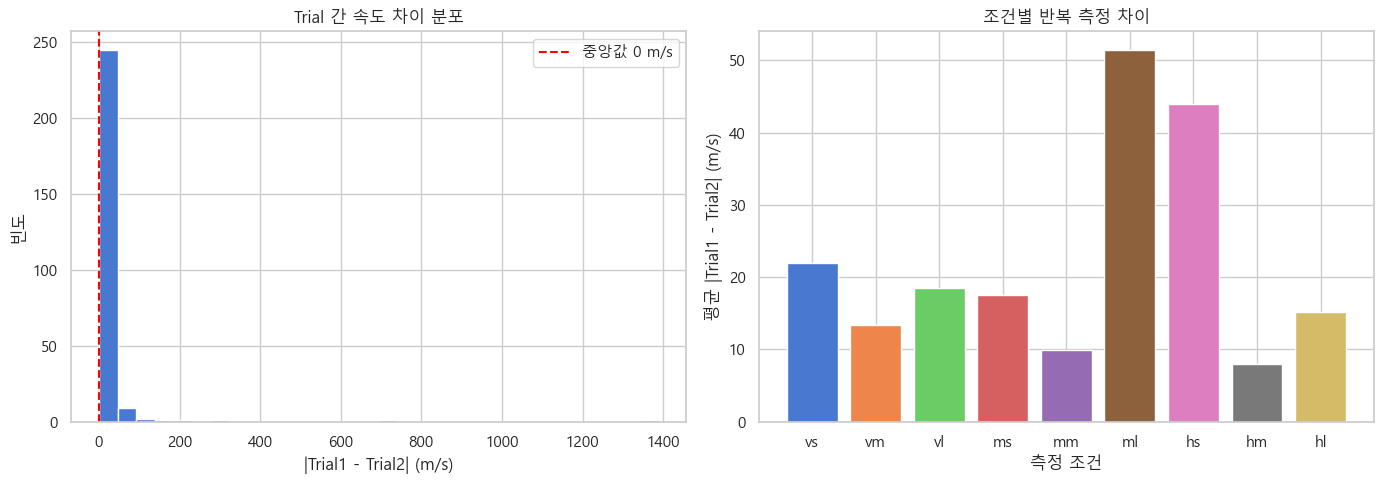

조건별 반복 측정 평균 차이 (m/s):
condition
vs    21.9
vm    13.4
vl    18.6
ms    17.5
mm     9.9
ml    51.4
hs    44.0
hm     8.0
hl    15.2


In [171]:
# 같은 내화물·조건의 trial 1과 trial 2 속도 차이
t1 = df[df['trial']==1].set_index(['sample_id','condition'])['velocity_mps']
t2 = df[df['trial']==2].set_index(['sample_id','condition'])['velocity_mps']
common = t1.index.intersection(t2.index)
diff = (t1.loc[common] - t2.loc[common]).abs().reset_index()
diff.columns = ['sample_id', 'condition', 'abs_diff_mps']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(diff['abs_diff_mps'], bins=30, edgecolor='white')
ax.axvline(diff['abs_diff_mps'].median(), color='red', linestyle='--',
           label=f"중앙값 {diff['abs_diff_mps'].median():.0f} m/s")
ax.set_xlabel('|Trial1 - Trial2| (m/s)')
ax.set_ylabel('빈도')
ax.set_title('Trial 간 속도 차이 분포')
ax.legend()

ax = axes[1]
diff_by_cond = diff.groupby('condition')['abs_diff_mps'].mean().reindex(cond_order)
ax.bar(cond_order, diff_by_cond, color=sns.color_palette('muted', 9))
ax.set_xlabel('측정 조건')
ax.set_ylabel('평균 |Trial1 - Trial2| (m/s)')
ax.set_title('조건별 반복 측정 차이')

plt.tight_layout()
plt.show()

print('조건별 반복 측정 평균 차이 (m/s):')
print(diff_by_cond.round(1).to_string())

## 9. 내화물별 속도 프로파일 (조건 간 변동)

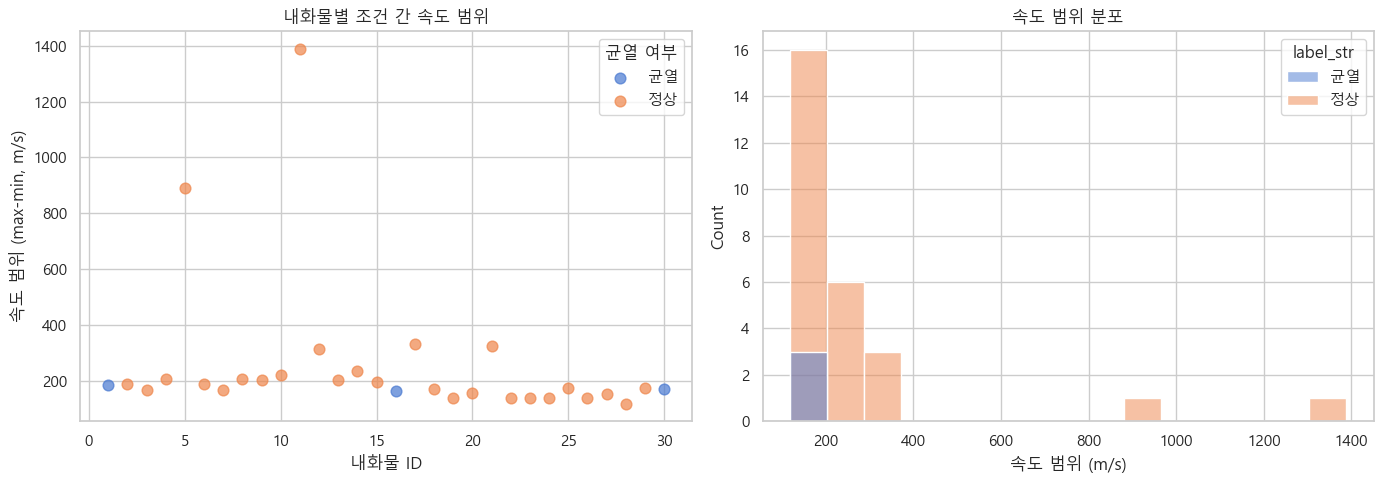

내화물별 조건 간 속도 변동 요약:
       range_mps    std
count       30.0   30.0
mean       253.4   71.8
std        255.2   53.7
min        119.0   42.6
25%        159.0   49.5
50%        181.0   59.0
75%        207.0   66.2
max       1388.0  312.8


In [172]:
# 내화물별 조건 간 속도 범위 (max - min)
sample_range = df.groupby('sample_id')['velocity_mps'].agg(
    min='min', max='max', std='std'
)
sample_range['range_mps'] = sample_range['max'] - sample_range['min']
sample_range = sample_range.join(
    df.drop_duplicates('sample_id').set_index('sample_id')['label_str']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for lbl, grp in sample_range.groupby('label_str'):
    ax.scatter(grp.index, grp['range_mps'], label=lbl, alpha=0.7, s=60)
ax.set_xlabel('내화물 ID')
ax.set_ylabel('속도 범위 (max-min, m/s)')
ax.set_title('내화물별 조건 간 속도 범위')
ax.legend(title='균열 여부')

ax = axes[1]
sns.histplot(data=sample_range, x='range_mps', hue='label_str', bins=15, ax=ax)
ax.set_xlabel('속도 범위 (m/s)')
ax.set_title('속도 범위 분포')

plt.tight_layout()
plt.show()

print('내화물별 조건 간 속도 변동 요약:')
print(sample_range[['range_mps','std']].describe().round(1))

## 10. 원시 파형 시각화

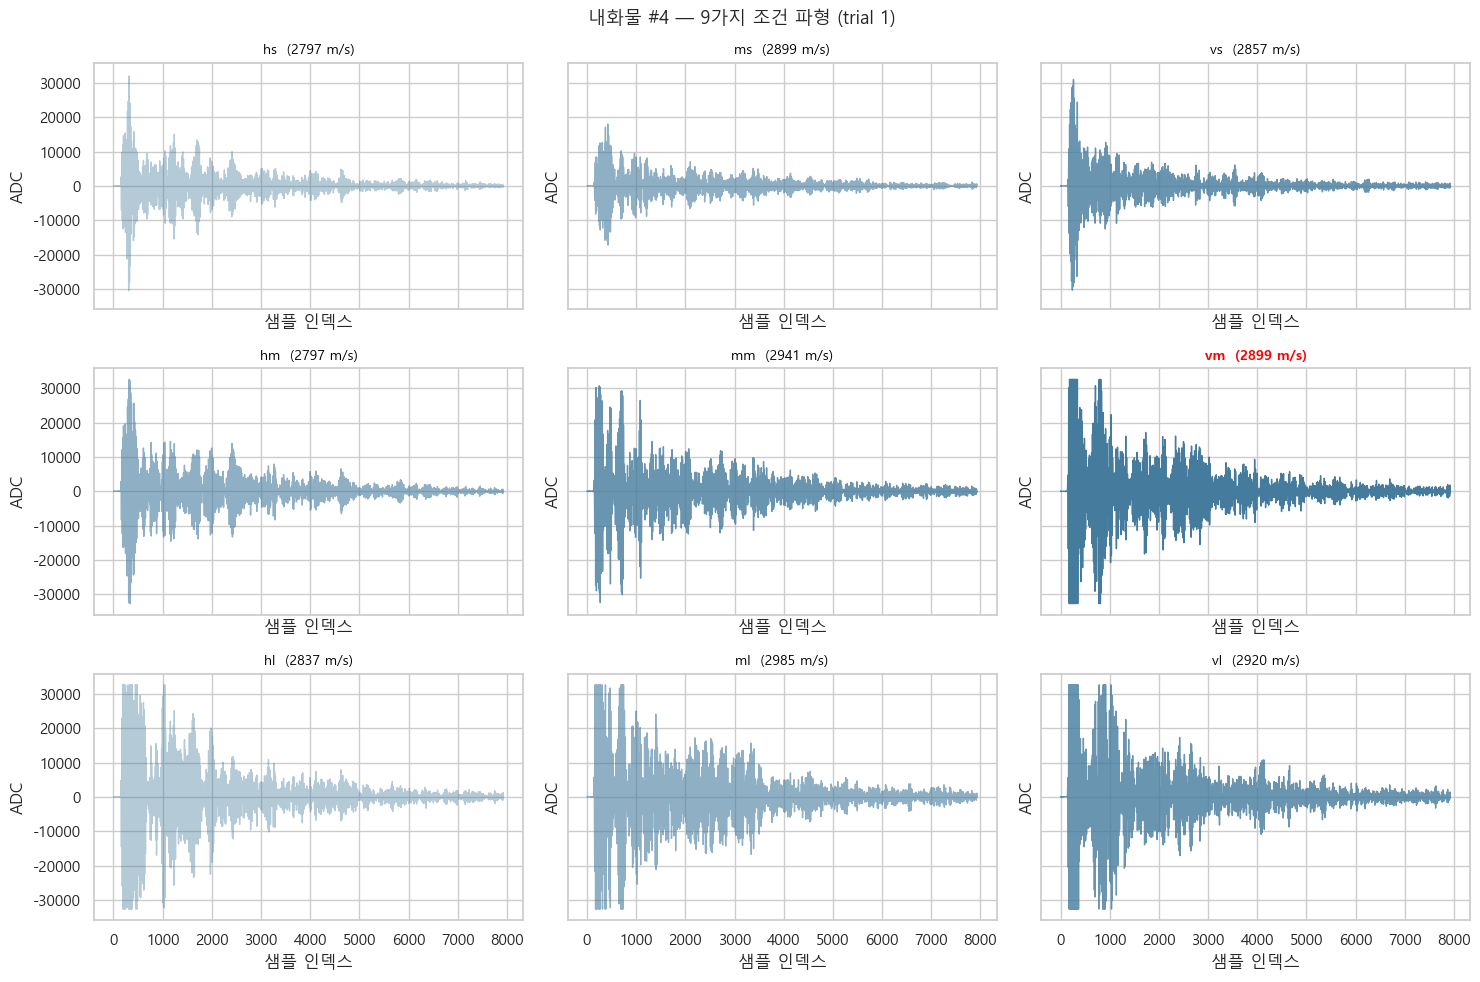

In [173]:
# 특정 내화물의 9가지 조건 파형 오버레이 (trial 1)
SAMPLE_ID = 4

gel_order   = ['s', 'm', 'l']
angle_order = ['h', 'm', 'v']
cond_grid   = [[a + g for a in angle_order] for g in gel_order]

# vm까지의 거리 기반으로 색상/투명도 결정
def cond_style(cond):
    angle_dist = {'v': 0, 'm': 1, 'h': 2}
    gel_dist   = {'s': 1, 'm': 0, 'l': 1}
    dist = angle_dist[cond[0]] + gel_dist[cond[1]]   # vm=0, 인접=1, 먼=2~3
    if dist == 0:   # vm — 강조
        return dict(color='#457B9D', alpha=1.0, linewidth=1.0, zorder=5)
    elif dist == 1:
        return dict(color='#457B9D', alpha=0.8, linewidth=1.0, zorder=3)
    elif dist == 2:
        return dict(color='#457B9D', alpha=0.6, linewidth=1.0, zorder=2)
    else:
        return dict(color='#457B9D', alpha=0.4, linewidth=1.0, zorder=1)

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
t_axis = np.arange(signal.shape[1])

for ax_row, cond_row in zip(axes, cond_grid):
    for ax, cond in zip(ax_row, cond_row):
        style = cond_style(cond)
        rows = df[(df['sample_id'] == SAMPLE_ID) &
                  (df['condition'] == cond) &
                  (df['trial'] == 1)].index
        if len(rows):
            idx  = rows[0]
            wav  = signal.iloc[idx].values
            vel  = df.loc[idx, 'velocity_mps']
            ax.plot(t_axis, wav, **style)
            ax.set_title(
                f'{cond}  ({vel:.0f} m/s)',
                fontsize=10,
                fontweight='bold' if cond == 'vm' else 'normal',
                color='red' if cond == 'vm' else 'black',
            )
        else:
            ax.set_title(f'{cond}  (없음)', fontsize=10, color='#aaa')
        ax.set_xlabel('샘플 인덱스')
        ax.set_ylabel('ADC')

fig.suptitle(f'내화물 #{SAMPLE_ID} — 9가지 조건 파형 (trial 1)', fontsize=13)
plt.tight_layout()
plt.show()

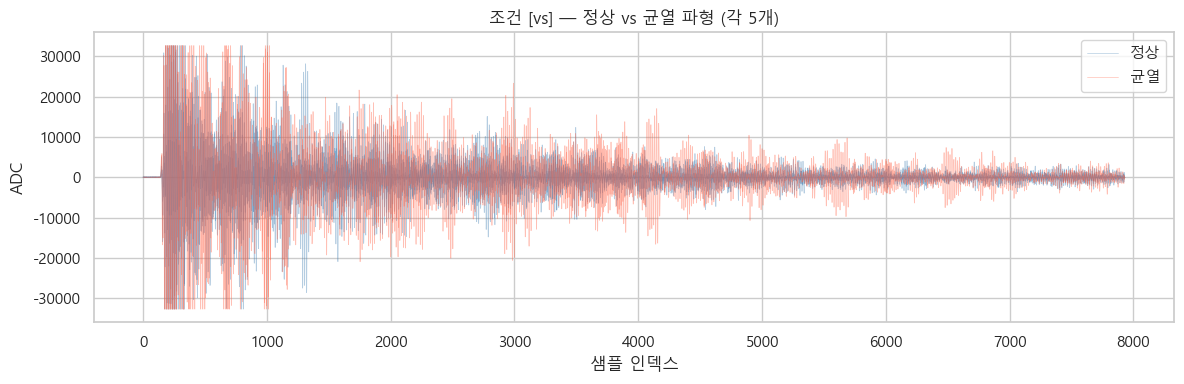

In [174]:
# 정상 vs 균열 대표 파형 비교 (조건 고정)
CONDITION = 'vs'

fig, ax = plt.subplots(figsize=(12, 4))
for lbl_val, lbl_str, color in [(0,'정상','steelblue'), (1,'균열','tomato')]:
    rows = df[(df['label']==lbl_val) & (df['condition']==CONDITION) & (df['trial']==1)].index
    for idx in rows[:5]:  # 최대 5개
        wav = signal.iloc[idx].values
        ax.plot(t_axis, wav, color=color, alpha=0.4, linewidth=0.5,
                label=lbl_str if idx == rows[0] else '')

ax.set_xlabel('샘플 인덱스')
ax.set_ylabel('ADC')
ax.set_title(f'조건 [{CONDITION}] — 정상 vs 균열 파형 (각 5개)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2])
plt.tight_layout()
plt.show()

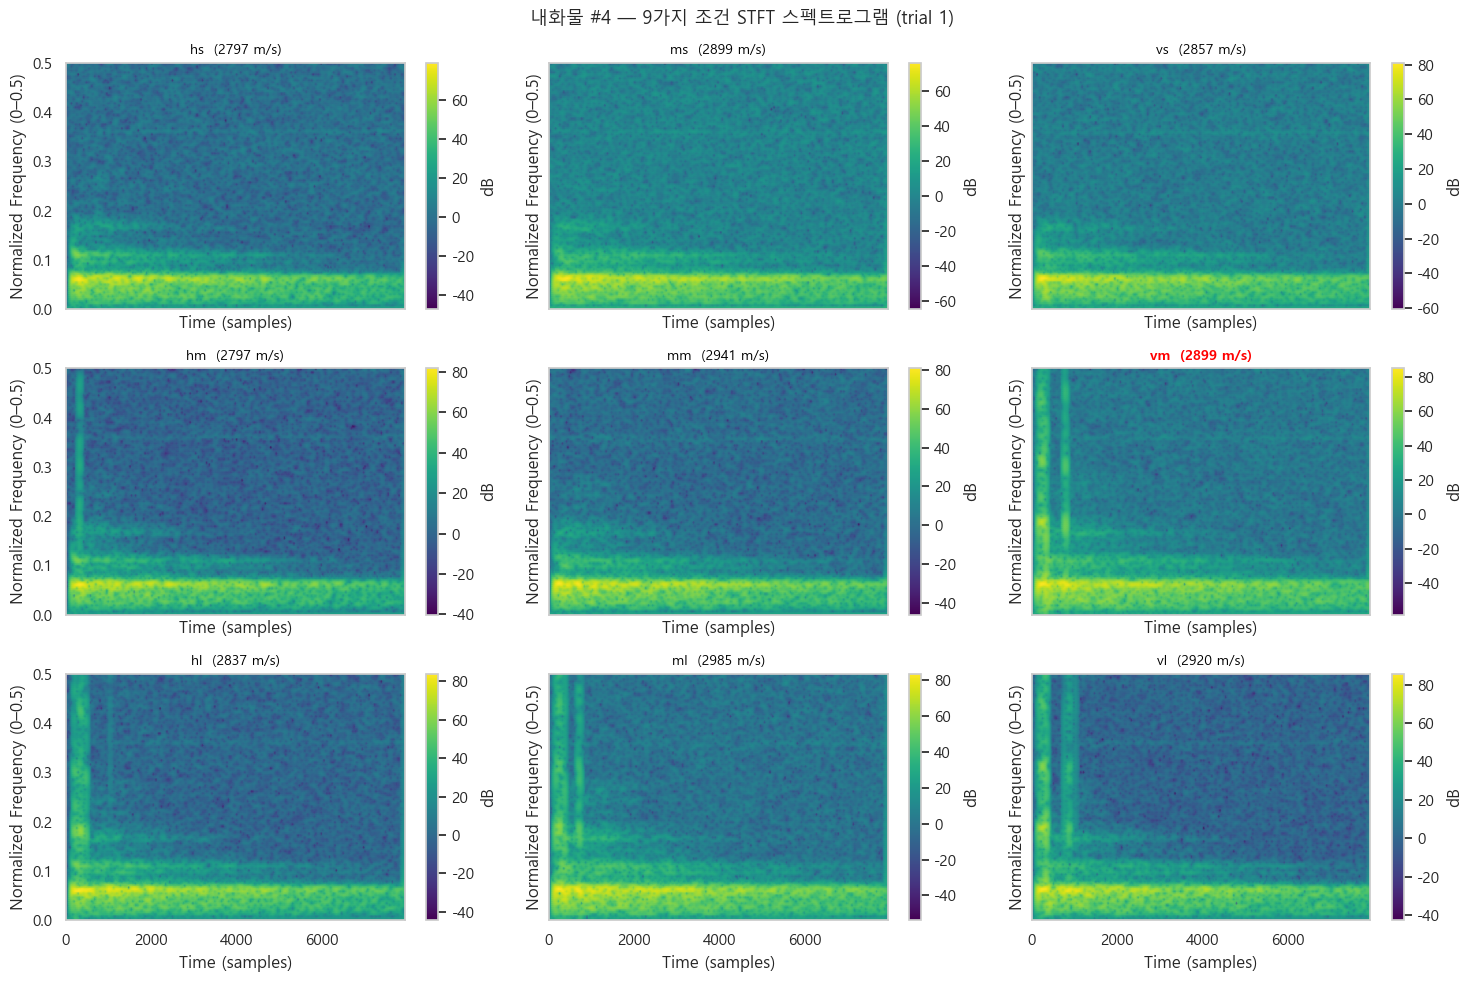

In [175]:
from scipy.signal import stft

# 실제 샘플링 주파수를 알면 여기에 입력 (단위: Hz)
# 모를 경우 FS=1 로 두면 정규화 주파수(0~0.5)로 표시됨
FS = 1

NPERSEG  = 256   # 윈도우 크기 (클수록 주파수 해상도 ↑, 시간 해상도 ↓)
NOVERLAP = 224   # 겹침 샘플 수

def compute_stft_db(waveform):
    f, t, Zxx = stft(waveform.astype(np.float32), fs=FS,
                     nperseg=NPERSEG, noverlap=NOVERLAP)
    return f, t, 20 * np.log10(np.abs(Zxx) + 1e-10)

freq_label = 'Frequency (Hz)' if FS > 1 else 'Normalized Frequency (0–0.5)'
time_label = 'Time (s)'       if FS > 1 else 'Time (samples)'

# # 특정 내화물의 9가지 조건 파형 오버레이 (trial 1) - STFT 버전
SAMPLE_ID = 4

plot_order = [
    'hs', 'ms', 'vs',
    'hm', 'mm', 'vm',
    'hl', 'ml', 'vl',
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)

for ax, cond in zip(axes.flat, plot_order):
    rows = df[(df['sample_id'] == SAMPLE_ID) &
              (df['condition'] == cond) &
              (df['trial'] == 1)].index
    if len(rows):
        idx  = rows[0]
        wav  = signal.iloc[idx].values
        f, t, Sdb = compute_stft_db(wav)
        im = ax.pcolormesh(t, f, Sdb, shading='gouraud', cmap='viridis')
        vel = df.loc[idx, 'velocity_mps']
        color  = 'red'  if cond == 'vm' else 'black'
        weight = 'bold' if cond == 'vm' else 'normal'
        ax.set_title(f'{cond}  ({vel:.0f} m/s)', fontsize=10,
                     color=color, fontweight=weight)
        plt.colorbar(im, ax=ax, label='dB')
    else:
        ax.set_title(f'{cond}  (없음)', fontsize=10)
    ax.set_xlabel(time_label)
    ax.set_ylabel(freq_label)

fig.suptitle(f'내화물 #{SAMPLE_ID} — 9가지 조건 STFT 스펙트로그램 (trial 1)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. 파형 특성 추출 — 기초 피처

In [176]:
# 파형 기반 간단 피처
sig_np = signal.values.astype(np.float32)

df['sig_max']    = sig_np.max(axis=1)
df['sig_min']    = sig_np.min(axis=1)
df['sig_peak2peak'] = df['sig_max'] - df['sig_min']
df['sig_rms']    = np.sqrt((sig_np**2).mean(axis=1))
df['sig_energy'] = (sig_np**2).sum(axis=1)

# 조건별 피처 분포
feat_cols = ['sig_peak2peak', 'sig_rms', 'sig_energy']
print(df.groupby('condition')[feat_cols].mean().reindex(cond_order).round(1))

           sig_peak2peak      sig_rms    sig_energy
condition                                          
vs          50729.300781  4170.700195  1.793443e+11
vm          60664.500000  5615.899902  2.887748e+11
vl          63617.000000  7246.899902  4.614876e+11
ms          41406.398438  3400.300049  1.232139e+11
mm          56484.398438  5277.600098  2.581439e+11
ml          59767.199219  6647.000000  4.023139e+11
hs          32158.000000  2422.800049  6.610362e+10
hm          52543.199219  4231.200195  1.690078e+11
hl          61356.898438  5582.799805  2.786720e+11


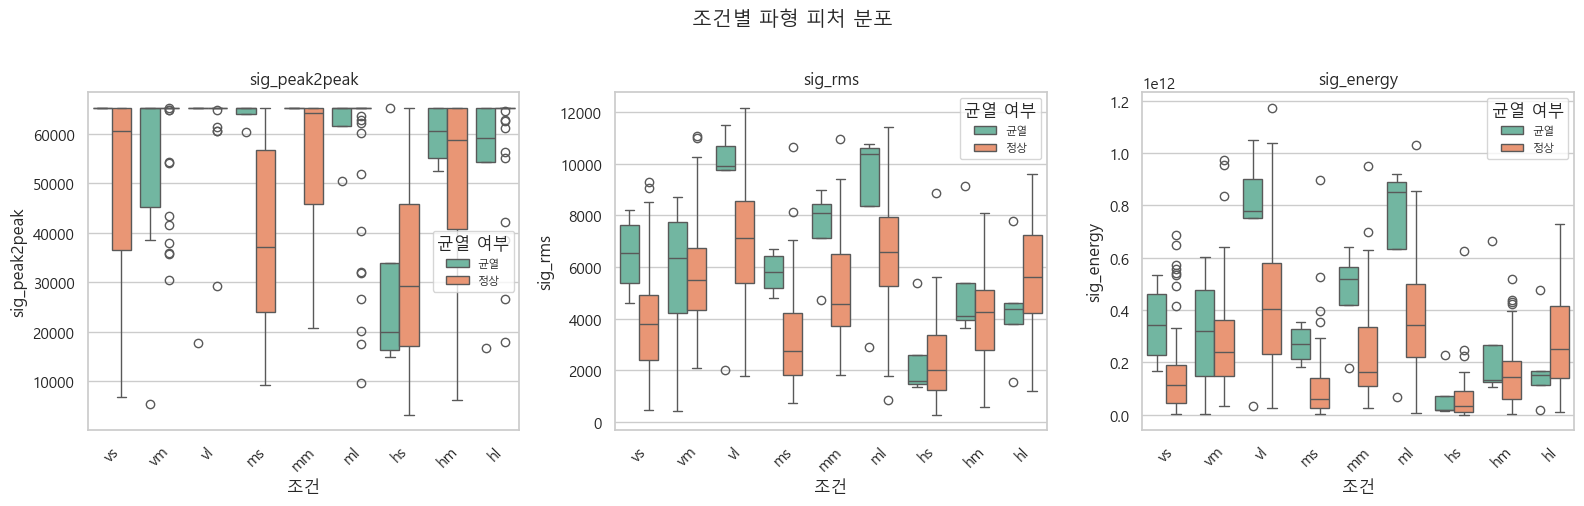

In [177]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, feat_cols):
    sns.boxplot(data=df, x='condition', y=feat, order=cond_order, ax=ax,
                hue='label_str', palette='Set2')
    ax.set_title(feat)
    ax.set_xlabel('조건')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='균열 여부', fontsize=8)
plt.suptitle('조건별 파형 피처 분포', y=1.01)
plt.tight_layout()
plt.show()

## 12. 상관 분석 — 속도 vs 파형 피처

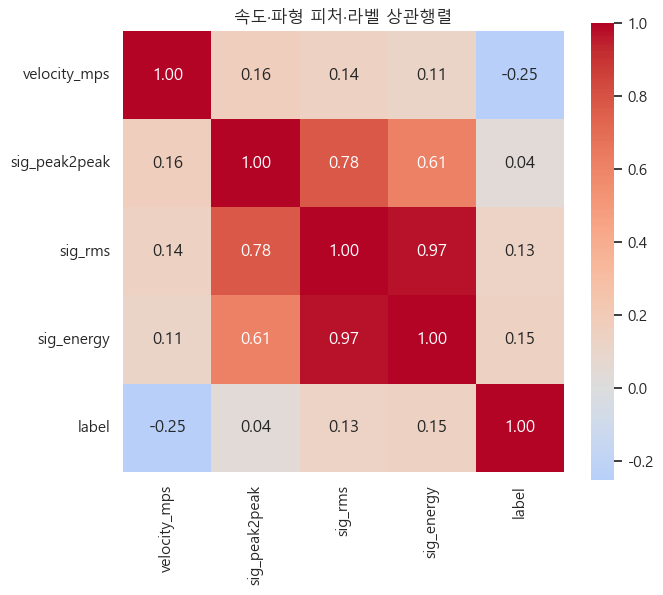

In [178]:
corr_cols = ['velocity_mps', 'sig_peak2peak', 'sig_rms', 'sig_energy', 'label']
corr_df = df[corr_cols].apply(pd.to_numeric, errors='coerce')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('속도·파형 피처·라벨 상관행렬')
plt.tight_layout()
plt.show()